
# 01 Corpus Descriptive Report


uses  `data` tables only (no PDF parsing/retrieval/cleaning )



In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures" / "01_notebook_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MONTHLY_SUMMARY_PATH = DATA_DIR / "corpus" / "monthly_summary.csv"
NEXIS_VOLUME_PATH = DATA_DIR / "corpus" / "monthly_nexis_volume.csv"

SALIENCE_COL = "nexis_total_results"
CLEANED_SAMPLE_COL = "kept_article_count"
DOWNLOAD_COL = "raw_article_count"

In [2]:

monthly = pd.read_csv(MONTHLY_SUMMARY_PATH)
nexis_volume = pd.read_csv(NEXIS_VOLUME_PATH)

In [3]:

expected_months = pd.period_range("2013-01", "2025-12", freq="M").astype(str)
expected_months_set = set(expected_months)

required_nexis_cols = {"month_id", "volume", "raw_article_count"}
missing_nexis_cols = required_nexis_cols - set(nexis_volume.columns)
assert not missing_nexis_cols, f"Missing required NEXIS columns: {missing_nexis_cols}"

assert len(nexis_volume) == 156, f"Expected 156 rows in monthly_nexis_volume.csv, found {len(nexis_volume)}"
assert not nexis_volume["month_id"].duplicated().any(), "Duplicate month_id in monthly_nexis_volume.csv"

found_months = set(nexis_volume["month_id"].astype(str))
missing_months = sorted(expected_months_set - found_months)
extra_months = sorted(found_months - expected_months_set)
assert not missing_months, f"Missing months in NEXIS volume file: {missing_months}"
assert not extra_months, f"Unexpected extra months in NEXIS volume file: {extra_months}"

for col in ["volume", "raw_article_count"]:
    nexis_volume[col] = pd.to_numeric(nexis_volume[col], errors="coerce")
    assert nexis_volume[col].notna().all(), f"Column {col} has non-numeric or missing values"

assert len(monthly) == 156, f"Expected 156 rows in monthly_summary, found {len(monthly)}"
assert "month_id" in monthly.columns, "monthly_summary must include month_id"
assert not monthly["month_id"].duplicated().any(), "Duplicate month_id in monthly_summary"

In [4]:

monthly2 = monthly.copy()
nexis2 = nexis_volume.rename(columns={"volume": "nexis_total_results", "raw_article_count": "raw_article_count_manual"}).copy()

if "raw_article_count" in monthly2.columns:
    monthly2 = monthly2.rename(columns={"raw_article_count": "raw_article_count_monthly"})
else:
    monthly2["raw_article_count_monthly"] = np.nan

vol = monthly2.merge(nexis2, on="month_id", how="left", validate="one_to_one")
vol["month_dt"] = pd.to_datetime(vol["month_id"] + "-01", errors="coerce")

vol["raw_article_count_mismatch"] = (
    vol["raw_article_count_monthly"].notna()
    & vol["raw_article_count_manual"].notna()
    & (vol["raw_article_count_monthly"] != vol["raw_article_count_manual"])
)

vol["raw_article_count"] = vol["raw_article_count_manual"].where(
    vol["raw_article_count_manual"].notna(), vol["raw_article_count_monthly"]
)

mismatch_rows = vol.loc[
    vol["raw_article_count_mismatch"],
    ["month_id", "raw_article_count_monthly", "raw_article_count_manual"],
].sort_values("month_id")

if len(mismatch_rows):
    display(mismatch_rows)

display(vol[["month_id", "nexis_total_results", "raw_article_count", "kept_article_count"]].head(12))

,month_id,nexis_total_results,raw_article_count,kept_article_count
0,2013-01,42,42,38
1,2013-02,55,55,41
2,2013-03,67,67,61
3,2013-04,63,63,55
4,2013-05,64,64,54
5,2013-06,83,83,71
6,2013-07,104,104,91
7,2013-08,146,146,130
8,2013-09,95,91,80
9,2013-10,151,141,125


In [5]:

                                                                                     
vol["media_salience_volume_raw"] = vol[SALIENCE_COL]
vol["media_salience_volume_log1p"] = np.log1p(vol[SALIENCE_COL])

sal_mean = vol[SALIENCE_COL].mean()
sal_std = vol[SALIENCE_COL].std(ddof=0)
vol["media_salience_volume_z"] = (vol[SALIENCE_COL] - sal_mean) / sal_std if pd.notna(sal_std) and sal_std != 0 else np.nan

vol["cleaned_sample_size"] = pd.to_numeric(vol[CLEANED_SAMPLE_COL], errors="coerce")
vol["cleaned_sample_log1p"] = np.log1p(vol["cleaned_sample_size"])
clean_mean = vol["cleaned_sample_size"].mean()
clean_std = vol["cleaned_sample_size"].std(ddof=0)
vol["cleaned_sample_z"] = (vol["cleaned_sample_size"] - clean_mean) / clean_std if pd.notna(clean_std) and clean_std != 0 else np.nan

valid_den = vol[SALIENCE_COL].notna() & (vol[SALIENCE_COL] > 0)
vol["download_fraction"] = np.where(valid_den, vol[DOWNLOAD_COL] / vol[SALIENCE_COL], np.nan)
vol["cleaned_sample_fraction"] = np.where(valid_den, vol[CLEANED_SAMPLE_COL] / vol[SALIENCE_COL], np.nan)

vol["retrieval_mismatch_flag"] = vol[DOWNLOAD_COL] > vol[SALIENCE_COL]
vol["high_download_sample_flag"] = vol[DOWNLOAD_COL] > 50

display(vol[[
    "month_id", "nexis_total_results", "raw_article_count", "kept_article_count",
    "download_fraction", "cleaned_sample_fraction", "retrieval_mismatch_flag", "high_download_sample_flag"
]].head(12))

,month_id,nexis_total_results,raw_article_count,kept_article_count,download_fraction,cleaned_sample_fraction,retrieval_mismatch_flag,high_download_sample_flag
0,2013-01,42,42,38,1.000000,0.904762,False,False
1,2013-02,55,55,41,1.000000,0.745455,False,True
2,2013-03,67,67,61,1.000000,0.910448,False,True
3,2013-04,63,63,55,1.000000,0.873016,False,True
4,2013-05,64,64,54,1.000000,0.843750,False,True
5,2013-06,83,83,71,1.000000,0.855422,False,True
6,2013-07,104,104,91,1.000000,0.875000,False,True
7,2013-08,146,146,130,1.000000,0.890411,False,True
8,2013-09,95,91,80,0.957895,0.842105,False,True
9,2013-10,151,141,125,0.933775,0.827815,False,True


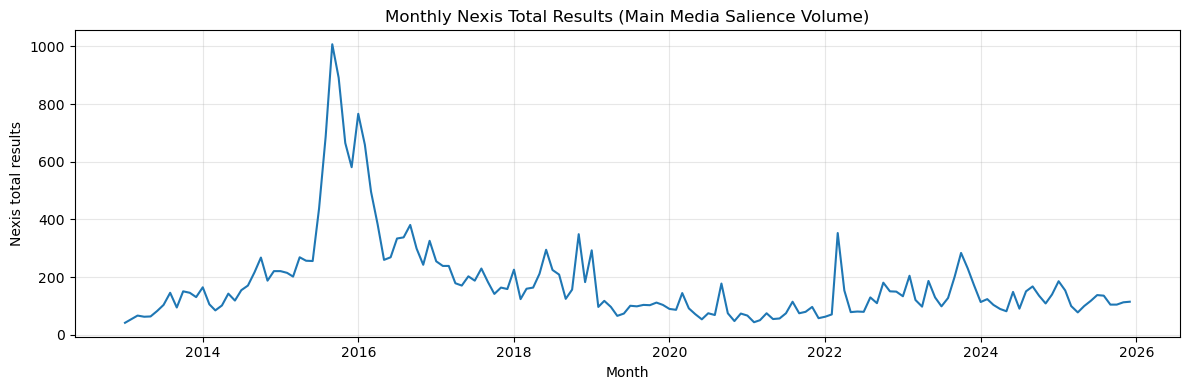

In [6]:

plt.figure(figsize=(12, 4))
plt.plot(vol["month_dt"], vol["nexis_total_results"], linewidth=1.5)
plt.title("Monthly Nexis Total Results (Main Media Salience Volume)")
plt.xlabel("Month")
plt.ylabel("Nexis total results")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_nexis_total_results_over_time_report.png", dpi=150)
plt.show()

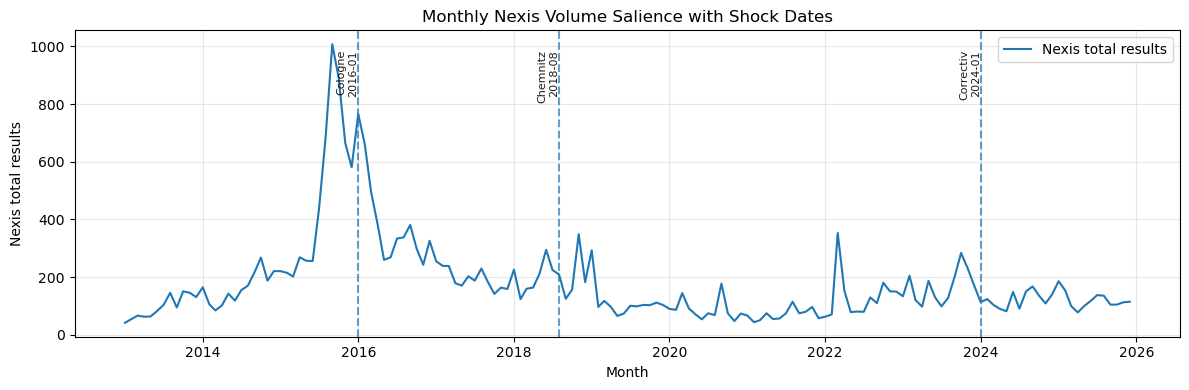

In [7]:
shock_meta = [
    {"label": "Cologne", "date": pd.Timestamp("2016-01-01")},
    {"label": "Chemnitz", "date": pd.Timestamp("2018-08-01")},
    {"label": "Correctiv", "date": pd.Timestamp("2024-01-01")},
]

plt.figure(figsize=(12, 4))
plt.plot(vol["month_dt"], vol["nexis_total_results"], linewidth=1.5, label="Nexis total results")

y_top = float(vol["nexis_total_results"].max()) * 0.98
for shock in shock_meta:
    d = shock["date"]
    plt.axvline(d, linestyle="--", alpha=0.7)
    plt.text(
        d,
        y_top,
        f"{shock['label']}\n{d.strftime('%Y-%m')}",
        rotation=90,
        va="top",
        ha="right",
        fontsize=8,
        alpha=0.9,
    )

plt.title("Monthly Nexis Volume Salience with Shock Dates")
plt.xlabel("Month")
plt.ylabel("Nexis total results")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_volume_salience_with_shock_dates.png", dpi=150)
plt.show()


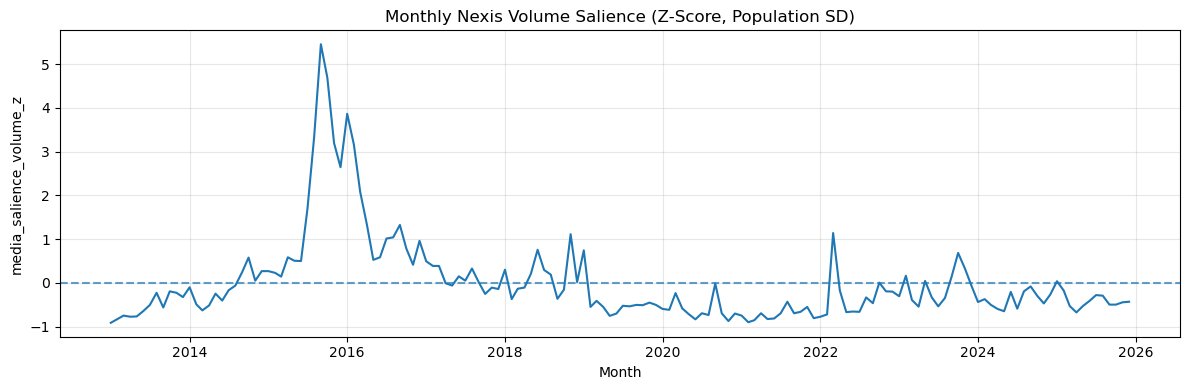

In [8]:

plt.figure(figsize=(12, 4))
plt.plot(vol["month_dt"], vol["media_salience_volume_z"], linewidth=1.5)
plt.axhline(0.0, linestyle="--", alpha=0.7)
plt.title("Monthly Nexis Volume Salience (Z-Score, Population SD)")
plt.xlabel("Month")
plt.ylabel("media_salience_volume_z")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_volume_salience_z_report.png", dpi=150)
plt.show()

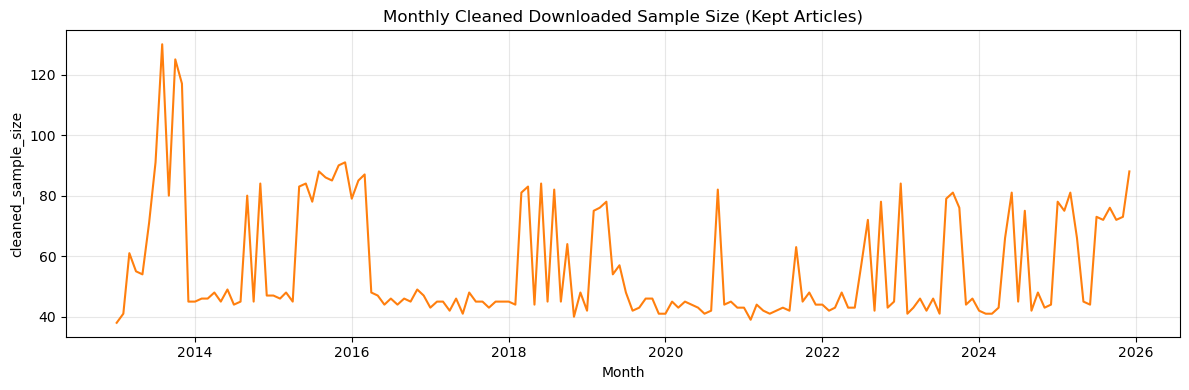

In [9]:

plt.figure(figsize=(12, 4))
plt.plot(vol["month_dt"], vol["cleaned_sample_size"], linewidth=1.5, color="tab:orange")
plt.title("Monthly Cleaned Downloaded Sample Size (Kept Articles)")
plt.xlabel("Month")
plt.ylabel("cleaned_sample_size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_cleaned_sample_size_over_time_report.png", dpi=150)
plt.show()

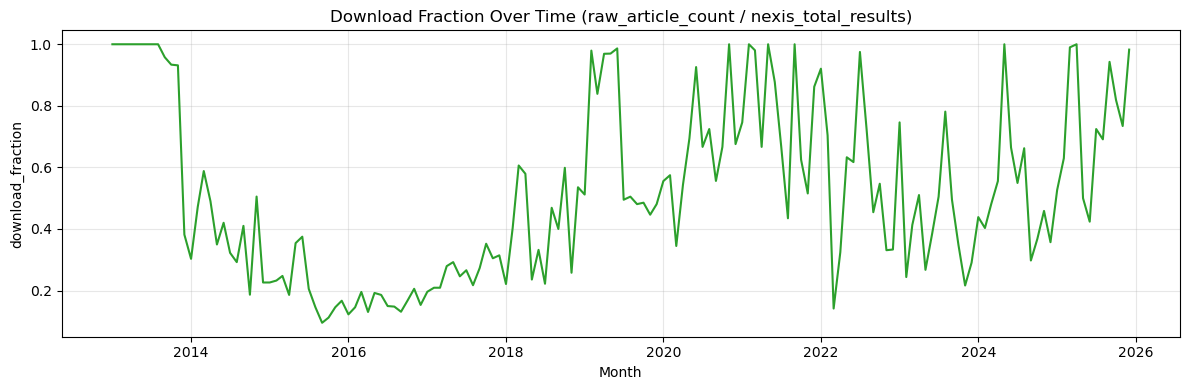

In [10]:

plt.figure(figsize=(12, 4))
plt.plot(vol["month_dt"], vol["download_fraction"], linewidth=1.5, color="tab:green")
plt.title("Download Fraction Over Time (raw_article_count / nexis_total_results)")
plt.xlabel("Month")
plt.ylabel("download_fraction")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "download_fraction_over_time_report.png", dpi=150)
plt.show()

In [11]:

display(
    vol.sort_values("nexis_total_results", ascending=False)
      [["month_id", "nexis_total_results", "media_salience_volume_z"]]
      .head(15)
)

display(
    vol[vol["media_salience_volume_z"] >= 2.0]
      .sort_values("media_salience_volume_z", ascending=False)
      [["month_id", "nexis_total_results", "media_salience_volume_z"]]
)

display(
    vol.sort_values("cleaned_sample_size", ascending=False)
      [["month_id", "cleaned_sample_size", "cleaned_sample_z"]]
      .head(15)
)

,month_id,nexis_total_results,media_salience_volume_z
32,2015-09,1007,5.450985
33,2015-10,891,4.686355
36,2016-01,766,3.862401
31,2015-08,687,3.341662
34,2015-11,665,3.196646
37,2016-02,659,3.157096
35,2015-12,581,2.642949
38,2016-03,496,2.082660
30,2015-07,438,1.700346
39,2016-04,383,1.337806


,month_id,nexis_total_results,media_salience_volume_z
32,2015-09,1007,5.450985
33,2015-10,891,4.686355
36,2016-01,766,3.862401
31,2015-08,687,3.341662
34,2015-11,665,3.196646
37,2016-02,659,3.157096
35,2015-12,581,2.642949
38,2016-03,496,2.082660


,month_id,cleaned_sample_size,cleaned_sample_z
7,2013-08,130,3.939175
9,2013-10,125,3.672159
10,2013-11,117,3.244933
6,2013-07,91,1.856448
35,2015-12,91,1.856448
34,2015-11,90,1.803045
155,2025-12,88,1.696238
31,2015-08,88,1.696238
38,2016-03,87,1.642835
32,2015-09,86,1.589432


In [12]:


display(
    vol[vol["retrieval_mismatch_flag"]]
      [["month_id", "raw_article_count", "nexis_total_results", "download_fraction"]]
      .sort_values("month_id")
)

display(
    vol[vol["high_download_sample_flag"]]
      [["month_id", "raw_article_count", "nexis_total_results", "download_fraction"]]
      .sort_values("month_id")
)

display(
    vol[["month_id", "download_fraction", "cleaned_sample_fraction"]].head(20)
)

,month_id,raw_article_count,nexis_total_results,download_fraction


,month_id,raw_article_count,nexis_total_results,download_fraction
1,2013-02,55,55,1.000000
2,2013-03,67,67,1.000000
3,2013-04,63,63,1.000000
4,2013-05,64,64,1.000000
5,2013-06,83,83,1.000000
6,2013-07,104,104,1.000000
7,2013-08,146,146,1.000000
8,2013-09,91,95,0.957895
9,2013-10,141,151,0.933775
10,2013-11,136,146,0.931507


,month_id,download_fraction,cleaned_sample_fraction
0,2013-01,1.000000,0.904762
1,2013-02,1.000000,0.745455
2,2013-03,1.000000,0.910448
3,2013-04,1.000000,0.873016
4,2013-05,1.000000,0.843750
5,2013-06,1.000000,0.855422
6,2013-07,1.000000,0.875000
7,2013-08,1.000000,0.890411
8,2013-09,0.957895,0.842105
9,2013-10,0.933775,0.827815


In [13]:

indicator = vol.copy()
indicator["month"] = indicator["month_id"]
indicator["year_month"] = indicator["month_id"]
indicator["year"] = indicator["month_dt"].dt.year
indicator["month_num"] = indicator["month_dt"].dt.month

out_cols = [
    "month",
    "year_month",
    "year",
    "month_num",
    "nexis_total_results",
    "media_salience_volume_raw",
    "media_salience_volume_log1p",
    "media_salience_volume_z",
    "raw_article_count",
    "download_fraction",
    "retrieval_mismatch_flag",
    "high_download_sample_flag",
    "kept_article_count",
    "cleaned_sample_size",
    "cleaned_sample_fraction",
    "cleaned_sample_log1p",
    "cleaned_sample_z",
]

merge_ready = indicator[out_cols].sort_values("month").reset_index(drop=True)

assert len(merge_ready) == 156, f"Expected 156 rows, found {len(merge_ready)}"
assert not merge_ready["month"].duplicated().any(), "Duplicate month rows in indicator"
assert merge_ready["nexis_total_results"].notna().all(), "Missing nexis_total_results in indicator"

out_csv = DATA_DIR / "indicators" / "monthly_media_salience_indicator.csv"
out_parquet = DATA_DIR / "indicators" / "monthly_media_salience_indicator.parquet"
merge_ready.to_csv(out_csv, index=False, encoding="utf-8-sig")
merge_ready.to_parquet(out_parquet, index=False)

display(merge_ready.head(12))

,month,year_month,year,month_num,nexis_total_results,media_salience_volume_raw,media_salience_volume_log1p,media_salience_volume_z,raw_article_count,download_fraction,retrieval_mismatch_flag,high_download_sample_flag,kept_article_count,cleaned_sample_size,cleaned_sample_fraction,cleaned_sample_log1p,cleaned_sample_z
0,2013-01,2013-01,2013,1,42,42,3.761200,-0.909941,42,1.000000,False,False,38,38,0.904762,3.663562,-0.973925
1,2013-02,2013-02,2013,2,55,55,4.025352,-0.824250,55,1.000000,False,True,41,41,0.745455,3.737670,-0.813715
2,2013-03,2013-03,2013,3,67,67,4.219508,-0.745150,67,1.000000,False,True,61,61,0.910448,4.127134,0.254350
3,2013-04,2013-04,2013,4,63,63,4.158883,-0.771517,63,1.000000,False,True,55,55,0.873016,4.025352,-0.066069
4,2013-05,2013-05,2013,5,64,64,4.174387,-0.764925,64,1.000000,False,True,54,54,0.843750,4.007333,-0.119473
5,2013-06,2013-06,2013,6,83,83,4.430817,-0.639684,83,1.000000,False,True,71,71,0.855422,4.276666,0.788383
6,2013-07,2013-07,2013,7,104,104,4.653960,-0.501260,104,1.000000,False,True,91,91,0.875000,4.521789,1.856448
7,2013-08,2013-08,2013,8,146,146,4.990433,-0.224411,146,1.000000,False,True,130,130,0.890411,4.875197,3.939175
8,2013-09,2013-09,2013,9,95,95,4.564348,-0.560585,91,0.957895,False,True,80,80,0.842105,4.394449,1.269012
9,2013-10,2013-10,2013,10,151,151,5.023881,-0.191453,141,0.933775,False,True,125,125,0.827815,4.836282,3.672159



## conclusion

Main monthly media salience indicator `nexis_total_results`
`raw_article_count` = sample size 
`kept_article_count` and `cleaned_sample_size` = cleaned downloaded text sample size

